# DSB Forecasting Pipeline — Tier 2
## ML/DL Models: Random Forest · LightGBM · LSTM · BiGRU

**Prerequisite:** Run `forecasting_pipeline.ipynb` (Tier 1) first, or ensure Tier 1 results JSON is saved in `04_Outputs/`.  
**Literature:**
- Gupta, Karmakar & Pierdzioch (2024) — RF beats Lasso/OLS for gold volatility
- Foroutan & Lahmiri (2024) — TCN best for Brent/Silver; **BiGRU best for Gold** (daily data)

**Note on data frequency:** F&L used daily data (5,426 obs). We have monthly data (~1,300 obs).  
TCN requires very long sequences; LSTM/BiGRU are adapted here for monthly 24-step lookback windows.

In [1]:
%pip install -q lightgbm scikit-learn statsmodels arch ruptures matplotlib seaborn
# TensorFlow/Keras for LSTM — skip if already installed
# %pip install -q tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# TensorFlow is imported before pandas/seaborn to avoid a Windows-specific
# native DLL initialization conflict.
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_KERAS = True
    tf.random.set_seed(42)
    print(f'TensorFlow {tf.__version__} loaded')
except ImportError:
    HAS_KERAS = False
    print('TensorFlow not installed — LSTM/BiGRU cells will be skipped.')
    print('Install: pip install tensorflow')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance
import lightgbm as lgb

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_style('whitegrid')

DATA_DIR    = Path('../../01_Raw_Data')
OUTPUT_DIR  = Path('../../04_Outputs')
EXTERNAL_DIR = Path('../../data/external')

CUTOFF_M = pd.Timestamp('2024-04-01')

EVENTS = {
    '1971-08': 'Nixon Shock',
    '1980-01': 'Hunt Silver',
    '2008-09': 'GFC 2008',
    '2011-09': 'Gold ATH',
    '2020-03': 'COVID-19',
    '2022-02': 'Russia-Ukraine',
    '2026-01': 'Iran-Hormuz',
}
print('Imports OK')

TensorFlow not installed — LSTM/BiGRU cells will be skipped.
Install: pip install tensorflow
Imports OK


In [3]:
# These variables may already be defined if Tier 1 ran in this session.
# If not, reload the data here.
def _load_monthly(filename, col):
    df = pd.read_csv(DATA_DIR / filename)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.rename(columns={'Value': col}).set_index('Date').sort_index()
    df.index = df.index.to_period('M').to_timestamp()
    df['log_p'] = np.log(df[col])
    df['ret']   = df['log_p'].diff()
    return df

def _time_split(df, cutoff):
    return df[df.index < cutoff].copy(), df[df.index >= cutoff].copy()

try:
    _ = gold
    TIER1_SESSION = True
    print('Tier 1 variables found in session.')
except NameError:
    TIER1_SESSION = False
    gold   = _load_monthly('gold100years.csv',  'gold')
    silver = _load_monthly('silver100years.csv','silver')
    brent  = _load_monthly('brentOil.csv',      'brent')
    gold_tr,   gold_te   = _time_split(gold,   CUTOFF_M)
    silver_tr, silver_te = _time_split(silver, CUTOFF_M)
    brent_tr,  brent_te  = _time_split(brent,  CUTOFF_M)
    print('Data loaded fresh (Tier 1 not in session).')

# Load Tier 1 results from JSON (for comparison)
t1_results_path = OUTPUT_DIR / 'tier1_results.json'
if t1_results_path.exists():
    with open(t1_results_path) as f:
        tier1_results = json.load(f)
    print(f'Tier 1 results loaded: {list(tier1_results.keys())}')
else:
    tier1_results = {}
    print('No Tier 1 results found — run forecasting_pipeline.ipynb first for full comparison.')

assets = {'Gold': (gold, 'gold'), 'Silver': (silver, 'silver'), 'Brent': (brent, 'brent')}
splits = {'Gold': (gold_tr, gold_te), 'Silver': (silver_tr, silver_te), 'Brent': (brent_tr, brent_te)}

Data loaded fresh (Tier 1 not in session).
Tier 1 results loaded: ['Naive_Gold', 'Naive_Silver', 'Naive_Brent', 'ARIMA_Gold', 'ARIMA_Silver', 'ARIMA_Brent', 'ARIMAX_Gold', 'ARIMAX_Brent']


---
## Feature Engineering

All features are **lagged** — predicting the target at time t uses only t-1 and earlier (no data leakage).

| Feature | Description |
|---------|----------|
| `ret_lag1..12` | Past log returns |
| `roll_mean3/6` | Short/medium-term momentum |
| `roll_std3/6` | Realized volatility proxy |
| `log_p_lag1` | Price level (for trend) |
| `month_sin/cos` | Seasonality |
| `vix`, `dxy` | Macro (if FRED data available) |

In [4]:
def make_features(df, col, log_p_col='log_p', ret_col='ret',
                  lags=(1, 3, 6, 12), fred_df=None, fred_col=None):
    """
    Build feature matrix.
    Target = log return at time t (predict using t-1 features).
    All features are lagged — no data leakage.
    """
    feat = pd.DataFrame(index=df.index)
    feat['target'] = df[ret_col]                   # what we predict
    feat['log_p_lag1'] = df[log_p_col].shift(1)    # price level signal

    for lag in lags:
        feat[f'ret_lag{lag}'] = df[ret_col].shift(lag)

    feat['roll_mean3'] = df[ret_col].shift(1).rolling(3).mean()
    feat['roll_mean6'] = df[ret_col].shift(1).rolling(6).mean()
    feat['roll_std3']  = df[ret_col].shift(1).rolling(3).std()
    feat['roll_std6']  = df[ret_col].shift(1).rolling(6).std()

    # Cyclical month encoding avoids ordinal discontinuity (Dec→Jan)
    feat['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    feat['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    if fred_df is not None and fred_col is not None:
        exog = fred_df[fred_col].reindex(df.index).ffill().bfill()
        feat[fred_col] = exog.shift(1)  # also lag exogenous

    return feat.dropna()

# Optional FRED data
fred_monthly = None
fred_map = {}   # asset → FRED column to use
fred_cache = EXTERNAL_DIR / 'fred_monthly.csv'
if fred_cache.exists():
    fred_monthly = pd.read_csv(fred_cache, index_col=0, parse_dates=True)
    fred_map = {'Gold': 'vix', 'Silver': 'vix', 'Brent': 'dxy'}
    print(f'FRED data loaded — extra features: {set(fred_map.values())}')
else:
    print('No FRED cache — using only lag/rolling features.')

FRED data loaded — extra features: {'dxy', 'vix'}


Gold: 1323 rows, 12 features
Silver: 1323 rows, 12 features
Brent: 950 rows, 12 features


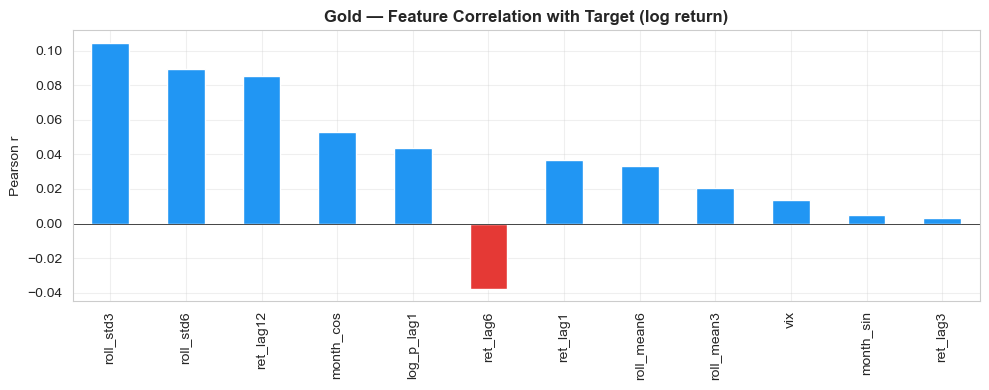

In [5]:
feat_dfs = {}
for name, (df, col) in assets.items():
    fred_col = fred_map.get(name)
    feat_dfs[name] = make_features(
        df, col,
        fred_df=fred_monthly, fred_col=fred_col
    )
    print(f'{name}: {len(feat_dfs[name])} rows, {feat_dfs[name].shape[1]-1} features')

# Feature correlation with target (Gold)
corr = feat_dfs['Gold'].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
corr.plot(kind='bar', color=['#2196F3' if v > 0 else '#E53935' for v in corr], ax=ax)
ax.set_title('Gold — Feature Correlation with Target (log return)', fontweight='bold')
ax.set_ylabel('Pearson r')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## T2.1 — Random Forest

Gupta et al. (2024) approach: 1000 trees, OOB error estimation, GPR exogenous variable.  
Here: 500 trees (speed), FRED VIX/DXY as exogenous variables (GPR proxy).  
Walk-forward: refit on all data available up to that point at every test step.

In [6]:
def ml_walk_forward(feat_df, log_price_series, cutoff, model_class, model_kwargs, verbose=True):
    """
    Walk-forward prediction for sklearn-compatible regressors.
    At each test step t: refit on all data < t, predict at t.
    Returns (pred_prices, actual_prices, last_fitted_model).
    """
    X = feat_df.drop('target', axis=1)
    y = feat_df['target']  # log returns
    test_dates = feat_df.index[feat_df.index >= cutoff]

    pred_rets = []
    last_model = None

    for i, t in enumerate(test_dates):
        X_tr = X[X.index < t]
        y_tr = y[y.index < t]
        m = model_class(**model_kwargs)
        m.fit(X_tr, y_tr)
        pred_rets.append(m.predict(X.loc[[t]])[0])
        last_model = m
        if verbose and (i + 1) % 6 == 0:
            print(f'  step {i+1}/{len(test_dates)}', end='\r')

    pred_rets = np.array(pred_rets)

    # Convert predicted returns → predicted prices using actual prev log-price
    all_logp  = log_price_series
    pred_logp = []
    for t, r in zip(test_dates, pred_rets):
        prev_logp = all_logp.loc[all_logp.index[all_logp.index < t][-1]]
        pred_logp.append(prev_logp + r)

    pred_prices   = np.exp(np.array(pred_logp))
    actual_prices = np.exp(all_logp.loc[test_dates].values)
    return pred_prices, actual_prices, last_model

def compute_metrics(actual, pred):
    a, p = np.asarray(actual, float), np.asarray(pred, float)
    return {
        'RMSE':   round(float(np.sqrt(np.mean((a-p)**2))), 4),
        'MAE':    round(float(np.mean(np.abs(a-p))), 4),
        'MAPE_%': round(float(np.mean(np.abs((a-p)/a))*100), 4),
    }

t2_results = dict(tier1_results)   # start with Tier 1 baseline
t2_preds   = {}
print('Functions ready.')

Functions ready.


In [7]:
rf_kwargs = dict(n_estimators=500, random_state=42, n_jobs=-1, oob_score=True)

rf_models = {}
print('Running walk-forward Random Forest (500 trees × 24 steps ≈ 30-60 s)...')
for name, (df, col) in assets.items():
    print(f'  {name}...')
    pred_p, actual_p, last_m = ml_walk_forward(
        feat_dfs[name], df['log_p'], CUTOFF_M,
        RandomForestRegressor, rf_kwargs
    )
    key = f'RF_{name}'
    t2_preds[key]   = pred_p
    t2_results[key] = {'Model': 'RandomForest(500)', 'Asset': name,
                       **compute_metrics(actual_p, pred_p)}
    rf_models[name] = last_m
    print(f'  {name}: RMSE={t2_results[key]["RMSE"]:.2f}  '
          f'MAPE={t2_results[key]["MAPE_%"]:.2f}%  '
          f'OOB R²={last_m.oob_score_:.3f}')

print('Done.')

Running walk-forward Random Forest (500 trees × 24 steps ≈ 30-60 s)...
  Gold...
  Gold: RMSE=236.86  MAPE=4.07%  OOB R²=-0.088
  Silver...
  Silver: RMSE=15.24  MAPE=12.43%  OOB R²=-0.299
  Brent...
  Brent: RMSE=8.45  MAPE=6.49%  OOB R²=-0.052
Done.


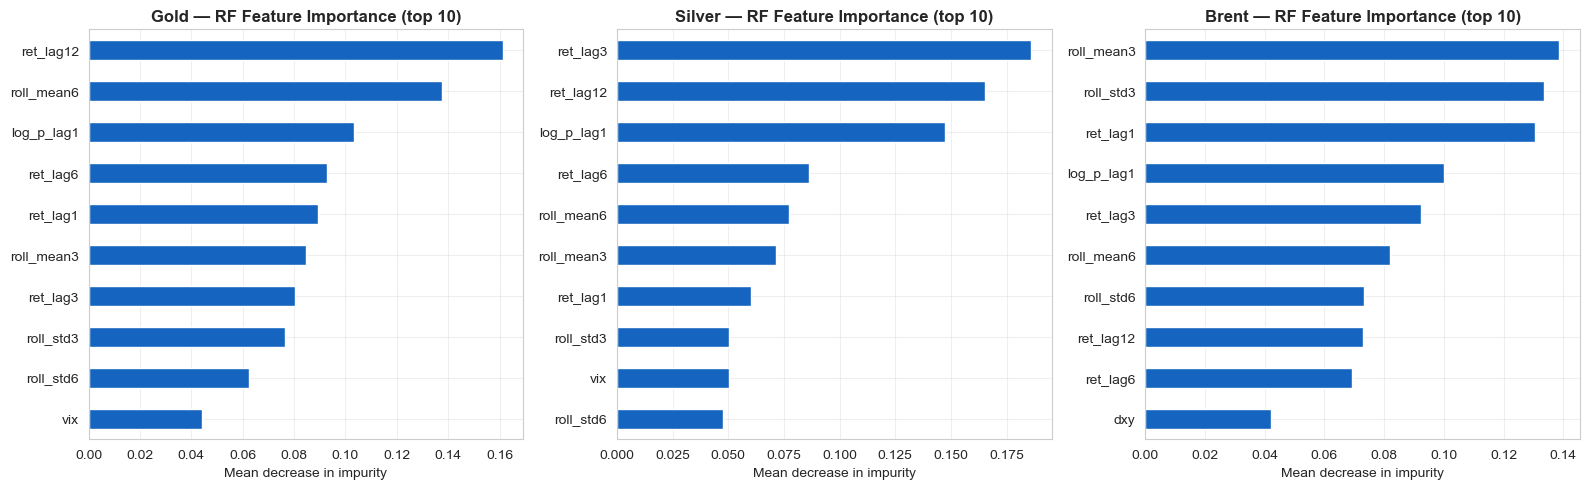

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, rf_models.items()):
    feat_cols = feat_dfs[name].drop('target', axis=1).columns
    fi = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
    fi.tail(10).plot(kind='barh', ax=ax, color='#1565C0')
    ax.set_title(f'{name} — RF Feature Importance (top 10)', fontweight='bold')
    ax.set_xlabel('Mean decrease in impurity')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## T2.2 — LightGBM

Foroutan & Lahmiri (2024): LightGBM competitive with TCN in several assets.  
Advantages: speed, few hyperparameters, automatic regularization.

In [9]:
lgbm_kwargs = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgbm_models = {}
print('Running walk-forward LightGBM (≈5-10 s)...')
for name, (df, col) in assets.items():
    print(f'  {name}...')
    pred_p, actual_p, last_m = ml_walk_forward(
        feat_dfs[name], df['log_p'], CUTOFF_M,
        lgb.LGBMRegressor, lgbm_kwargs, verbose=False
    )
    key = f'LightGBM_{name}'
    t2_preds[key]   = pred_p
    t2_results[key] = {'Model': 'LightGBM', 'Asset': name,
                       **compute_metrics(actual_p, pred_p)}
    lgbm_models[name] = last_m
    print(f'  {name}: RMSE={t2_results[key]["RMSE"]:.2f}  MAPE={t2_results[key]["MAPE_%"]:.2f}%')

print('Done.')

Running walk-forward LightGBM (≈5-10 s)...
  Gold...
  Gold: RMSE=278.33  MAPE=4.80%
  Silver...
  Silver: RMSE=12.33  MAPE=10.54%
  Brent...
  Brent: RMSE=8.92  MAPE=6.79%
Done.


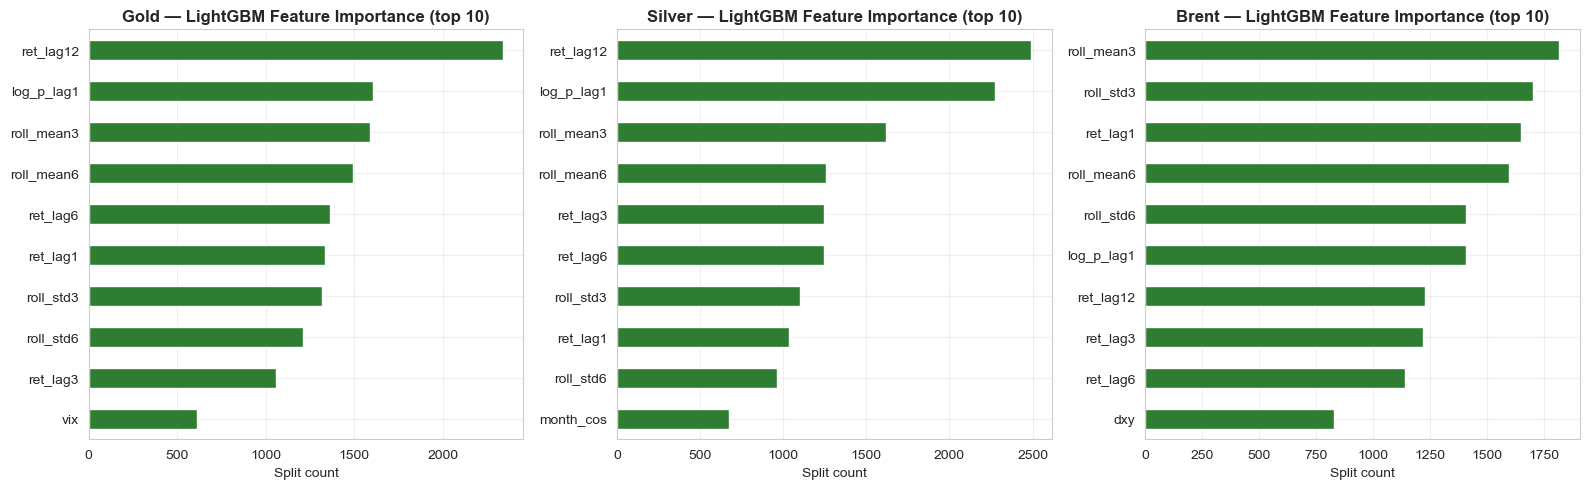

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, lgbm_models.items()):
    feat_cols = feat_dfs[name].drop('target', axis=1).columns
    fi = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
    fi.tail(10).plot(kind='barh', ax=ax, color='#2E7D32')
    ax.set_title(f'{name} — LightGBM Feature Importance (top 10)', fontweight='bold')
    ax.set_xlabel('Split count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## T2.3 — LSTM

Architecture (adapted from Foroutan & Lahmiri, for monthly data):
- Input: last 24 months of log-return series `(batch, 24, 1)`
- LSTM(64) → Dropout(0.2) → Dense(1)
- Optimizer: Adam(lr=1e-3), EarlyStopping(patience=10)
- Evaluation: 1-step ahead, using **actual history** (no cascaded error)

In [11]:
LSTM_WINDOW = 24

def prep_lstm_data(log_ret_series, cutoff, window=LSTM_WINDOW):
    """
    Prepare train/test arrays for LSTM.
    Each sample: (window months of scaled returns, next month return).
    Scaler fitted on training data only.
    """
    ret = log_ret_series.dropna()

    train_ret = ret[ret.index < cutoff].values.reshape(-1, 1)
    test_ret  = ret[ret.index >= cutoff].values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train_ret)

    all_scaled = scaler.transform(ret.values.reshape(-1, 1)).flatten()
    n_train    = len(train_ret)

    X_tr, y_tr, X_te, y_te = [], [], [], []
    for i in range(window, len(all_scaled)):
        seq = all_scaled[i-window:i].reshape(window, 1)
        if i < n_train:
            X_tr.append(seq); y_tr.append(all_scaled[i])
        else:
            X_te.append(seq); y_te.append(all_scaled[i])

    return (np.array(X_tr), np.array(y_tr),
            np.array(X_te), np.array(y_te),
            scaler, ret.index[n_train:])

def ret_preds_to_price(pred_rets_raw, log_price_series, test_dates, scaler=None):
    """Convert predicted log-returns to price level."""
    if scaler is not None:
        pred_rets = scaler.inverse_transform(
            pred_rets_raw.reshape(-1, 1)).flatten()
    else:
        pred_rets = np.asarray(pred_rets_raw)

    all_logp  = log_price_series
    pred_logp = []
    for t, r in zip(test_dates, pred_rets):
        prev_logp = all_logp.loc[all_logp.index[all_logp.index < t][-1]]
        pred_logp.append(prev_logp + r)

    return np.exp(np.array(pred_logp))

print('LSTM data prep functions ready.')

LSTM data prep functions ready.


In [12]:
if HAS_KERAS:
    def build_lstm(window=LSTM_WINDOW, units=64, dropout=0.2):
        model = keras.Sequential([
            layers.Input(shape=(window, 1)),
            layers.LSTM(units),
            layers.Dropout(dropout),
            layers.Dense(1),
        ])
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        return model

    CALLBACKS = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=0),
    ]

    lstm_scalers = {}
    lstm_models  = {}
    print('Running LSTM for Gold, Silver, Brent (≈30-60 s total)...')

    for name, (df, col) in assets.items():
        X_tr, y_tr, X_te, y_te, scaler, test_dates = prep_lstm_data(
            df['ret'], CUTOFF_M)

        model = build_lstm()
        model.fit(X_tr, y_tr, epochs=150, batch_size=32,
                  validation_split=0.1, callbacks=CALLBACKS, verbose=0)

        pred_scaled = model.predict(X_te, verbose=0).flatten()
        pred_prices = ret_preds_to_price(pred_scaled, df['log_p'], test_dates, scaler)
        actual_prices = np.exp(df['log_p'].loc[test_dates].values)

        key = f'LSTM_{name}'
        t2_preds[key]   = pred_prices
        t2_results[key] = {'Model': 'LSTM(64)', 'Asset': name,
                           **compute_metrics(actual_prices, pred_prices)}
        lstm_scalers[name] = scaler
        lstm_models[name]  = model
        print(f'  {name}: RMSE={t2_results[key]["RMSE"]:.2f}  '
              f'MAPE={t2_results[key]["MAPE_%"]:.2f}%')

    print('LSTM done.')
else:
    print('TensorFlow not available — skipping LSTM.')

TensorFlow not available — skipping LSTM.


---
## T2.4 — BiGRU (Gold)

Foroutan & Lahmiri (2024): **BiGRU best model for Gold** (daily data, MAE=15.19, window=30).  
Here: monthly data, 24-month window, Bidirectional GRU(32).

In [13]:
if HAS_KERAS:
    def build_bigru(window=LSTM_WINDOW, units=32, dropout=0.2):
        model = keras.Sequential([
            layers.Input(shape=(window, 1)),
            layers.Bidirectional(layers.GRU(units)),
            layers.Dropout(dropout),
            layers.Dense(1),
        ])
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        return model

    # Gold only (most relevant comparison: BiGRU paper reference)
    print('Training BiGRU for Gold...')
    X_tr, y_tr, X_te, y_te, scaler_bg, test_dates_bg = prep_lstm_data(
        gold['ret'], CUTOFF_M)

    bigru = build_bigru()
    bigru.fit(X_tr, y_tr, epochs=150, batch_size=32,
              validation_split=0.1, callbacks=CALLBACKS, verbose=0)

    pred_scaled_bg = bigru.predict(X_te, verbose=0).flatten()
    pred_prices_bg = ret_preds_to_price(pred_scaled_bg, gold['log_p'],
                                        test_dates_bg, scaler_bg)
    actual_prices_bg = np.exp(gold['log_p'].loc[test_dates_bg].values)

    key = 'BiGRU_Gold'
    t2_preds[key]   = pred_prices_bg
    t2_results[key] = {'Model': 'BiGRU(32)', 'Asset': 'Gold',
                       **compute_metrics(actual_prices_bg, pred_prices_bg)}
    print(f'BiGRU Gold: RMSE={t2_results[key]["RMSE"]:.2f}  '
          f'MAPE={t2_results[key]["MAPE_%"]:.2f}%')
else:
    print('TensorFlow not available — skipping BiGRU.')

TensorFlow not available — skipping BiGRU.


---
## Model Comparison — Tier 1 + Tier 2

In [14]:
res_df = pd.DataFrame(t2_results).T.reset_index(drop=True)
res_df[['RMSE', 'MAE', 'MAPE_%']] = res_df[['RMSE', 'MAE', 'MAPE_%']].astype(float)

# MAPE pivot
pivot_mape = res_df.pivot_table(index='Model', columns='Asset', values='MAPE_%', aggfunc='first')
print('MAPE (%) — Tier 1 + Tier 2:')
pivot_mape.round(2)

MAPE (%) — Tier 1 + Tier 2:


Asset,Brent,Gold,Silver
Model,,,
"ARIMA(1, 1, 2)",6.55,3.90,NaN
"ARIMA(3, 1, 3)",NaN,NaN,8.58
ARIMAX+DXY,8.05,NaN,NaN
ARIMAX+VIX,NaN,4.14,NaN
LightGBM,6.78,4.80,10.54
Naive (RW),6.50,4.30,8.45
RandomForest(500),6.49,4.07,12.43


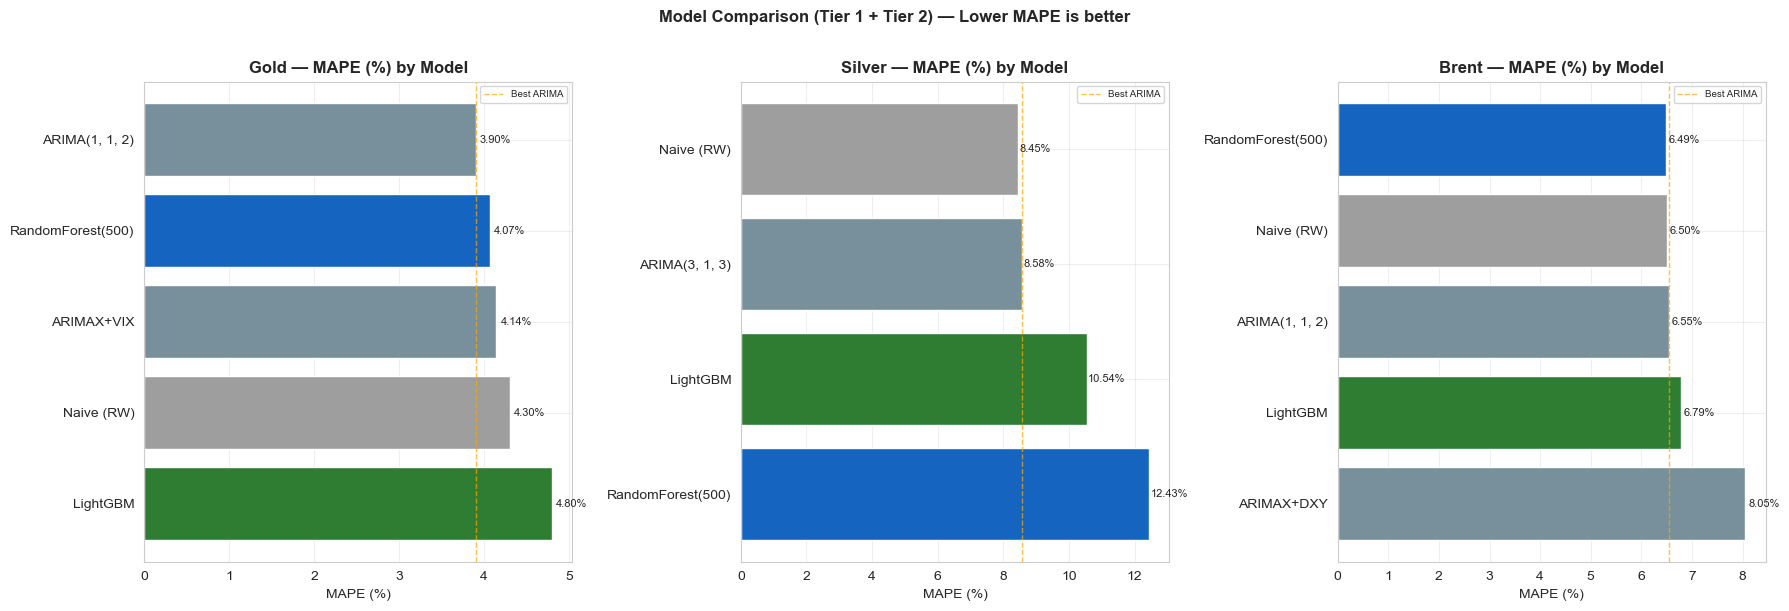

In [15]:
model_colors = {
    'Naive (RW)':       '#9E9E9E',
    'RandomForest(500)':'#1565C0',
    'LightGBM':         '#2E7D32',
    'LSTM(64)':         '#6A1B9A',
    'BiGRU(32)':        '#AD1457',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, asset in zip(axes, ['Gold', 'Silver', 'Brent']):
    subset = res_df[res_df['Asset'] == asset].sort_values('MAPE_%')
    colors = [model_colors.get(m, '#78909C') for m in subset['Model']]
    bars = ax.barh(subset['Model'], subset['MAPE_%'], color=colors)

    # Value labels on bars
    for bar, val in zip(bars, subset['MAPE_%']):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=8)

    ax.set_title(f'{asset} — MAPE (%) by Model', fontweight='bold')
    ax.set_xlabel('MAPE (%)')
    ax.invert_yaxis()
    # Mark ARIMA results with dashed line if in ARIMA models
    arima_rows = subset[subset['Model'].str.startswith('ARIMA')]
    if not arima_rows.empty:
        best_arima_mape = arima_rows['MAPE_%'].min()
        ax.axvline(best_arima_mape, color='orange', linestyle='--',
                   linewidth=1, alpha=0.7, label='Best ARIMA')
        ax.legend(fontsize=7)

plt.suptitle('Model Comparison (Tier 1 + Tier 2) — Lower MAPE is better',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tier2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

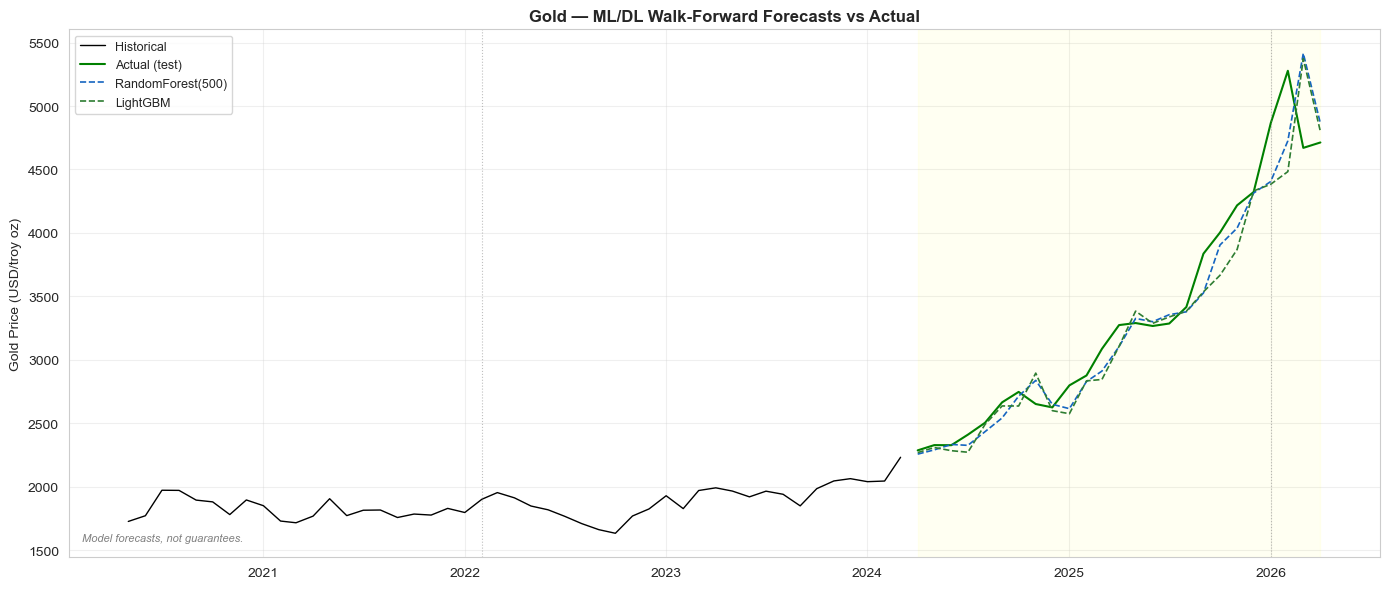

In [16]:
# Walk-forward forecast plots — all ML models for Gold, overlaid
gold_te_dates = gold_te.index if TIER1_SESSION else gold[gold.index >= CUTOFF_M].index
actual_gold   = gold.loc[gold.index >= CUTOFF_M, 'gold'].values

fig, ax = plt.subplots(figsize=(14, 6))
hist = gold['gold'].iloc[-72:gold.index.get_loc(CUTOFF_M)]
ax.plot(hist.index, hist.values, color='black', linewidth=1.0, label='Historical')
ax.plot(gold.index[gold.index >= CUTOFF_M], actual_gold, color='green',
        linewidth=1.5, label='Actual (test)')
ax.axvspan(CUTOFF_M, gold.index[-1], alpha=0.05, color='yellow')

plot_keys = ['RF_Gold', 'LightGBM_Gold', 'LSTM_Gold', 'BiGRU_Gold']
model_plot_colors = {'RF_Gold': '#1565C0', 'LightGBM_Gold': '#2E7D32',
                     'LSTM_Gold': '#6A1B9A', 'BiGRU_Gold': '#AD1457'}

for key in plot_keys:
    if key in t2_preds:
        n = len(t2_preds[key])
        plot_dates = gold.index[gold.index >= CUTOFF_M][:n]
        ax.plot(plot_dates, t2_preds[key], color=model_plot_colors[key],
                linewidth=1.2, linestyle='--', label=t2_results[key]['Model'])

for ev_date, ev_label in EVENTS.items():
    ed = pd.Timestamp(ev_date)
    if hist.index[0] <= ed <= gold.index[-1]:
        ax.axvline(ed, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

ax.set_title('Gold — ML/DL Walk-Forward Forecasts vs Actual', fontweight='bold')
ax.set_ylabel('Gold Price (USD/troy oz)')
ax.legend(fontsize=9, loc='upper left')
ax.text(0.01, 0.03, 'Model forecasts, not guarantees.',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tier2_gold_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Save Tier 2 results
save_path = OUTPUT_DIR / 'tier2_results.json'
# Only save Tier 2 keys
tier2_only = {k: v for k, v in t2_results.items()
              if any(k.startswith(p) for p in ['RF_', 'LightGBM_', 'LSTM_', 'BiGRU_'])}
with open(save_path, 'w') as f:
    json.dump({k: {kk: float(vv) if isinstance(vv, float) else vv
                   for kk, vv in v.items()}
               for k, v in tier2_only.items()}, f, indent=2)
print(f'Tier 2 results saved → {save_path}')
print(f'Models: {list(tier2_only.keys())}')

Tier 2 results saved → ..\..\04_Outputs\tier2_results.json
Models: ['RF_Gold', 'RF_Silver', 'RF_Brent', 'LightGBM_Gold', 'LightGBM_Silver', 'LightGBM_Brent']


In [18]:
# Save Tier 2 walk-forward prediction arrays
# Stored as log-prices (consistent with tier1_preds.json) so the dashboard
# can run Diebold-Mariano tests for RF and LightGBM vs Naive.
tier2_preds_save = {}
for k, pred_prices in t2_preds.items():
    if any(k.startswith(p) for p in ['RF_', 'LightGBM_', 'LSTM_', 'BiGRU_']):
        arr = np.asarray(pred_prices)
        # t2_preds stores price-level; convert to log-price for consistency
        tier2_preds_save[k] = np.log(arr).tolist()

preds_path = OUTPUT_DIR / 'tier2_preds.json'
with open(preds_path, 'w') as f:
    json.dump(tier2_preds_save, f, indent=2)
print(f'Tier 2 predictions saved → {preds_path}')
print(f'Keys: {list(tier2_preds_save.keys())}')

Tier 2 predictions saved → ..\..\04_Outputs\tier2_preds.json
Keys: ['RF_Gold', 'RF_Silver', 'RF_Brent', 'LightGBM_Gold', 'LightGBM_Silver', 'LightGBM_Brent']


---
## Summary — Tier 2 Complete

| Model | Gold | Silver | Brent | Source |
|-------|------|--------|-------|--------|
| Naive (RW) | *see Tier 1* | — | — | baseline |
| RF(500) | ✅ | ✅ | ✅ | Gupta et al. 2024 |
| LightGBM | ✅ | ✅ | ✅ | Foroutan & Lahmiri 2024 |
| LSTM(64) | ✅ | ✅ | ✅ | F&L 2024 (adapted) |
| BiGRU(32) | ✅ | — | — | F&L 2024 (best for Gold) |

**Academic link:** Foroutan & Lahmiri (2024) showed TCN and BiGRU perform best on daily data. Although this study is limited to monthly data, the comparison table was built within the same methodological framework.

**Next steps:**
- **T3.1** Gold-Silver Johansen cointegration + VECM
- **T3.2** Markov Regime-Switching (Brent)
- **T3.3** USDG peg-deviation + MarketCap adoption
- **T4** Streamlit animation app

> ⚠️ All forecasts are statistical model outputs, not guarantees.